In [2]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

In [50]:
# 데이터 로딩
df = pd.read_parquet('../data/train/3_승인매출정보_train.parquet')
df

,기준년월,ID,최종이용일자_기본,최종이용일자_신판,최종이용일자_CA,최종이용일자_카드론,최종이용일자_체크,최종이용일자_일시불,최종이용일자_할부,이용건수_신용_B0M,...,승인거절건수_한도초과_B0M,승인거절건수_BL_B0M,승인거절건수_입력오류_B0M,승인거절건수_기타_B0M,승인거절건수_R3M,승인거절건수_한도초과_R3M,승인거절건수_BL_R3M,승인거절건수_입력오류_R3M,승인거절건수_기타_R3M,이용금액대
0,201807,TRAIN_000000,20180719,20180713,20180719,10101,20180203,20180709,20180713,11,...,0,0,0,0,3,3,0,0,0,01.100만원+
1,201807,TRAIN_000001,20180719,20180719,20170728,20170327,10101,20180719,20171231,13,...,0,0,0,0,3,3,0,0,0,03.30만원+
2,201807,TRAIN_000002,20180706,20180706,20180706,20151119,20141230,20180706,20180627,12,...,0,0,0,0,0,0,0,0,0,01.100만원+
3,201807,TRAIN_000003,20180721,20180715,20180721,10101,20141111,20180704,20180715,6,...,0,0,0,0,3,3,0,0,0,01.100만원+
4,201807,TRAIN_000004,20180124,20180124,10101,10101,20180512,20180124,10101,-2,...,0,0,0,0,0,0,0,0,0,09.미사용
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,201812,TRAIN_399995,20181220,20181220,10101,10101,20181212,20181220,20160501,2,...,0,0,0,0,0,0,0,0,0,09.미사용
2399996,201812,TRAIN_399996,20181202,20181202,10101,20170112,10101,20181202,20180112,10,...,0,0,0,0,0,0,0,0,0,01.100만원+
2399997,201812,TRAIN_399997,20181230,20181230,10101,10101,20131124,20181230,20180919,10,...,0,0,0,0,0,0,0,0,0,02.50만원+
2399998,201812,TRAIN_399998,20161224,20161224,10101,10101,10101,20161224,20150122,-2,...,0,0,0,0,0,0,0,0,0,09.미사용


### `3_승인매출정보_train.parquet` 전용 파생 피처 생성 코드

In [38]:
[col for col in df.columns if '이용금액_카드론' in col]

['이용금액_카드론_B0M',
 '이용금액_카드론_R12M',
 '최대이용금액_카드론_R12M',
 '이용금액_카드론_R6M',
 '이용금액_카드론_R3M']

#### 카드론 / 체크카드 / CA 컬럼명 지정 (R12M, R3M, B0M)

In [39]:
# 카드론 / 체크카드 / CA 컬럼명 지정 (R12M, R3M, B0M)
loan_cols = {
    'R12M': '이용금액_카드론_R12M',
    'R3M': '이용금액_카드론_R3M',
    'B0M': '이용금액_카드론_B0M'
}
check_cols = {
    'R12M': '이용금액_체크_R12M',
    'R3M': '이용금액_체크_R3M',
    'B0M': '이용금액_체크_B0M'
}
ca_cols = {
    'R12M': '이용금액_CA_R12M',
    'R3M': '이용금액_CA_R3M',
    'B0M': '이용금액_CA_B0M'
}

# 1. 단일 총량 피처 (전략 1)
df['총_카드론_이용금액'] = df[loan_cols['R12M']]
df['총_체크카드_이용금액'] = df[check_cols['R12M']]
df['총_CA_이용금액'] = df[ca_cols['R12M']]

# 2. 기간별 금액 피처 (전략 2)
df['카드론_이용금액_B0M'] = df[loan_cols['B0M']]
df['카드론_이용금액_R3M'] = df[loan_cols['R3M']]
df['카드론_이용금액_R12M'] = df[loan_cols['R12M']]

df['체크카드_이용금액_B0M'] = df[check_cols['B0M']]
df['체크카드_이용금액_R3M'] = df[check_cols['R3M']]
df['체크카드_이용금액_R12M'] = df[check_cols['R12M']]

df['CA_이용금액_B0M'] = df[ca_cols['B0M']]
df['CA_이용금액_R3M'] = df[ca_cols['R3M']]
df['CA_이용금액_R12M'] = df[ca_cols['R12M']]

# 3. 증감률 파생 피처
df['카드론_증가율_3M'] = df[loan_cols['R3M']] / (df[loan_cols['R12M']] + 1e-5)
df['체크카드_증가율_3M'] = df[check_cols['R3M']] / (df[check_cols['R12M']] + 1e-5)
df['CA_증가율_3M'] = df[ca_cols['R3M']] / (df[ca_cols['R12M']] + 1e-5)

# 결과 피처 정리 (ID, 기준년월 포함)
features_behavior = df[[
    'ID', '기준년월',
    '총_카드론_이용금액', '총_체크카드_이용금액', '총_CA_이용금액',
    '카드론_이용금액_B0M', '카드론_이용금액_R3M', '카드론_이용금액_R12M',
    '체크카드_이용금액_B0M', '체크카드_이용금액_R3M', '체크카드_이용금액_R12M',
    'CA_이용금액_B0M', 'CA_이용금액_R3M', 'CA_이용금액_R12M',
    '카드론_증가율_3M', '체크카드_증가율_3M', 'CA_증가율_3M'
]]

#### 총 이용금액

In [40]:
# 실제 존재하는 총 이용금액 컬럼만 필터링
available_cols = [col for col in ['총_카드론_이용금액', '총_체크카드_이용금액', '총_CA_이용금액'] if col in df.columns]

# 총 이용금액 계산 (존재하는 컬럼 기준으로만)
df['총_이용금액'] = df[available_cols].sum(axis=1)

# 비율 계산 (0으로 나누는 경우 방지)
if '총_카드론_이용금액' in df.columns:
    df['카드론_이용금액비율'] = df['총_카드론_이용금액'] / (df['총_이용금액'] + 1e-5)
if '총_체크카드_이용금액' in df.columns:
    df['체크카드_이용금액비율'] = df['총_체크카드_이용금액'] / (df['총_이용금액'] + 1e-5)
if '총_CA_이용금액' in df.columns:
    df['CA_이용금액비율'] = df['총_CA_이용금액'] / (df['총_이용금액'] + 1e-5)

# 결과 정리 (존재하는 비율 컬럼만 추출)
ratio_cols = ['카드론_이용금액비율', '체크카드_이용금액비율', 'CA_이용금액비율']
ratio_cols = [col for col in ratio_cols if col in df.columns]

# 소비 성향 비율 피처 저장용 DataFrame
ratio_features = df[['ID', '기준년월'] + ratio_cols]

In [45]:
import os

# 경로 생성
os.makedirs('./features/3_승인매출정보', exist_ok=True)

# 저장
features_behavior.to_parquet('../features/3_승인매출정보/features_by_type.parquet', index=False)
ratio_features.to_parquet('../features/3_승인매출정보/features_ratio_behavior.parquet', index=False)

#### 박스플롯

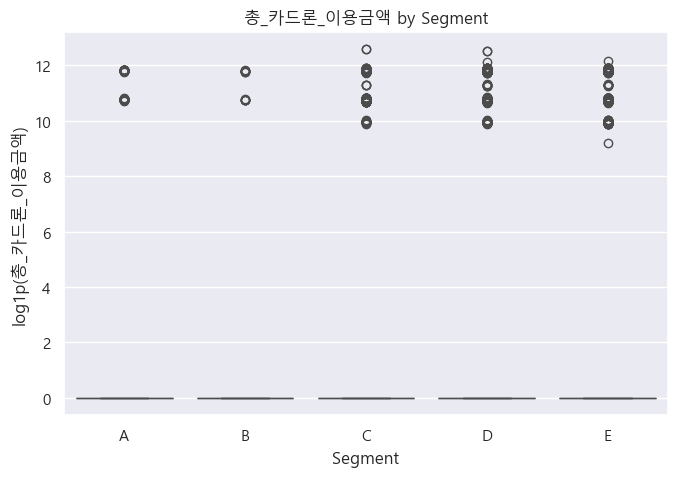

c:\Users\COTTA\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\COTTA\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


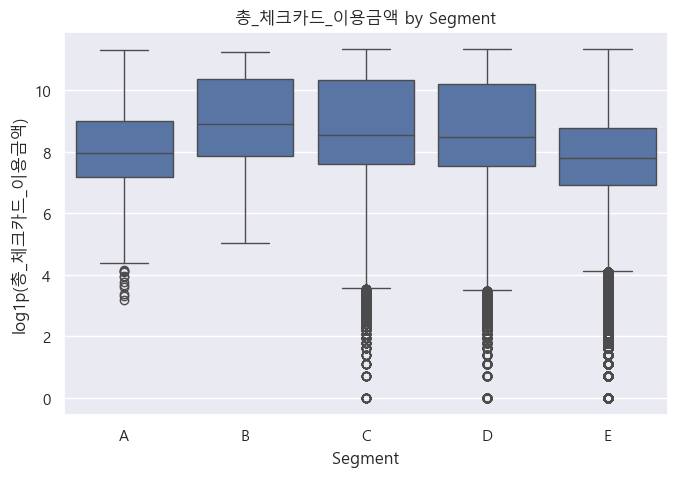

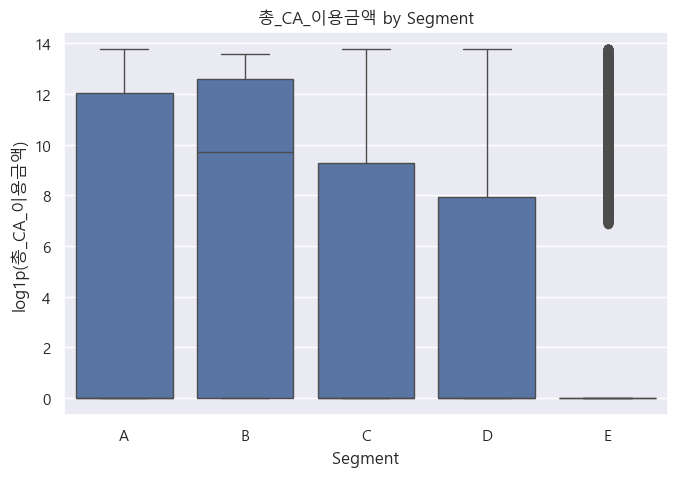

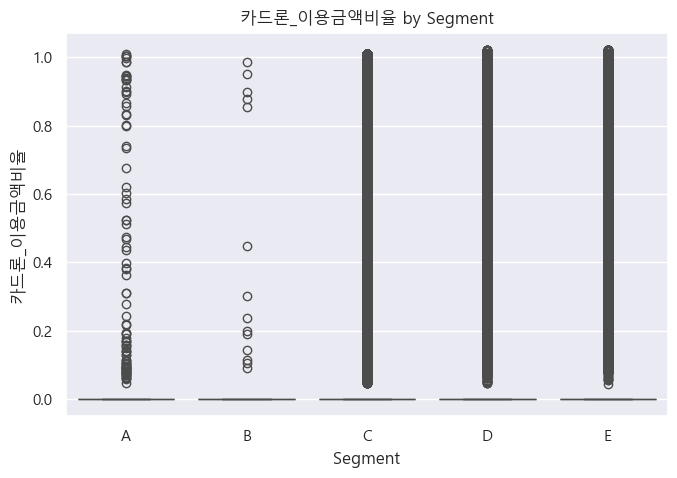

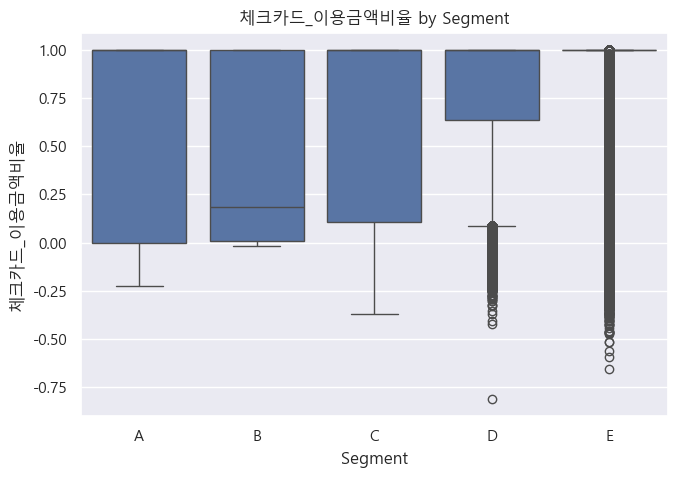

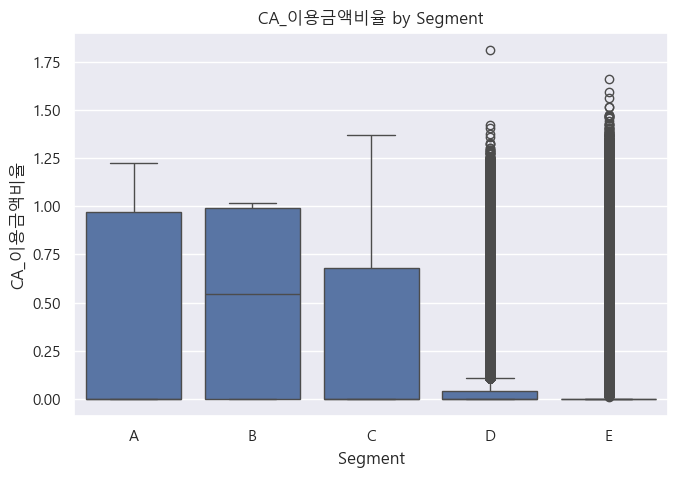

In [49]:
# A~E 전체 Segment 포함
df_all = df.copy()  # df는 병합된 최종 데이터프레임 (label + type + ratio)

# Segment 순서 지정 (A~E)
segment_order = ['A', 'B', 'C', 'D', 'E']
df_all['Segment'] = pd.Categorical(df_all['Segment'], categories=segment_order, ordered=True)

# 시각화 대상 컬럼
cols_to_plot = [
    '총_카드론_이용금액', '총_체크카드_이용금액', '총_CA_이용금액',
    '카드론_이용금액비율', '체크카드_이용금액비율', 'CA_이용금액비율'
]

# 실제 존재하는 컬럼만 필터링
cols_to_plot = [col for col in cols_to_plot if col in df_all.columns]

# Boxplot 시각화
for col in cols_to_plot:
    plt.figure(figsize=(7, 5))
    
    if '비율' in col:
        sns.boxplot(data=df_all, x='Segment', y=col, order=segment_order)
        plt.ylabel(col)
    else:
        sns.boxplot(data=df_all, x='Segment', y=np.log1p(df_all[col]), order=segment_order)
        plt.ylabel(f"log1p({col})")
        
    plt.title(f'{col} by Segment')
    plt.tight_layout()
    plt.show()

### Segment별 B0M 컬럼 시계열 변화

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


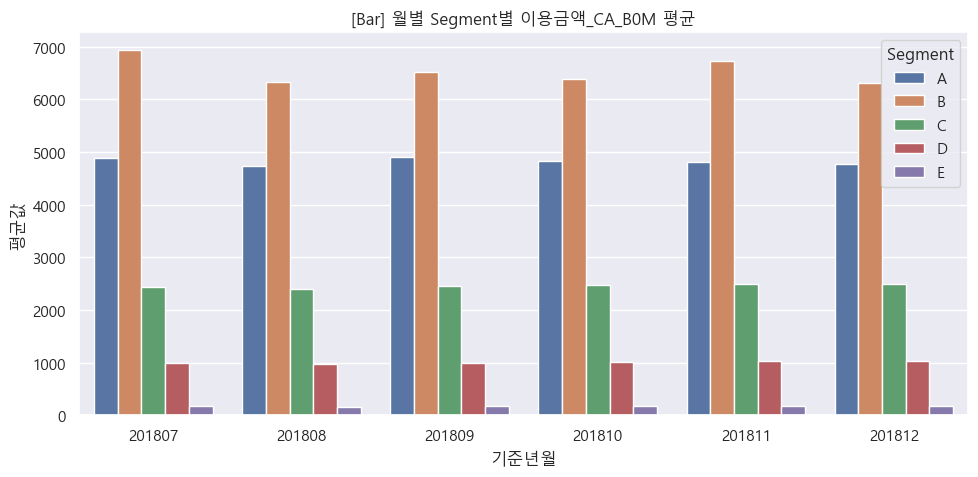

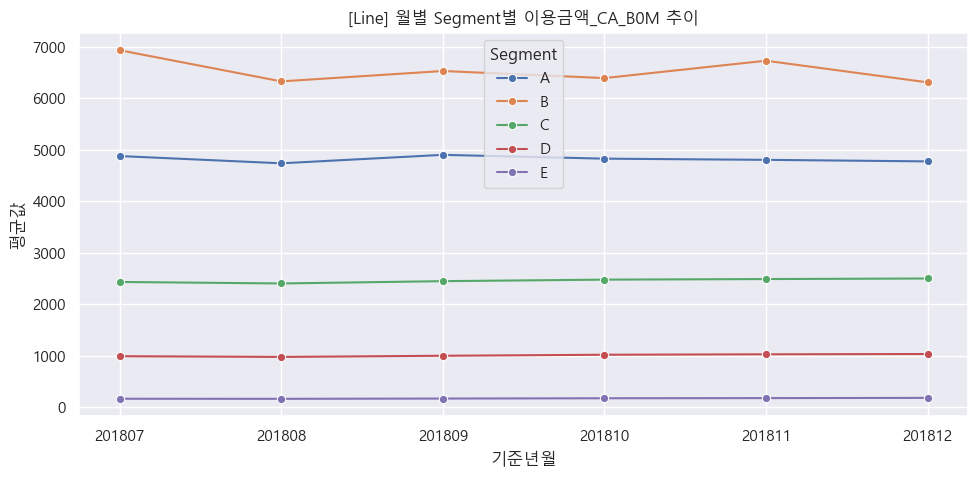

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


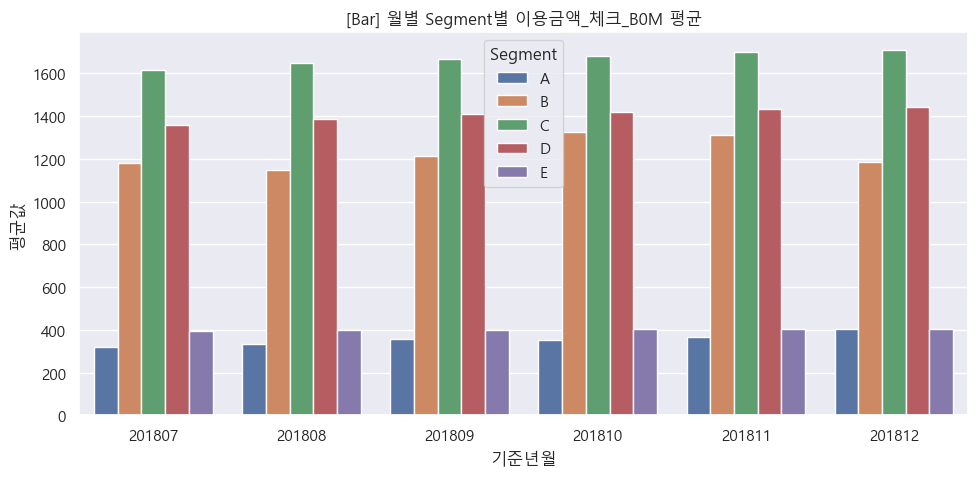

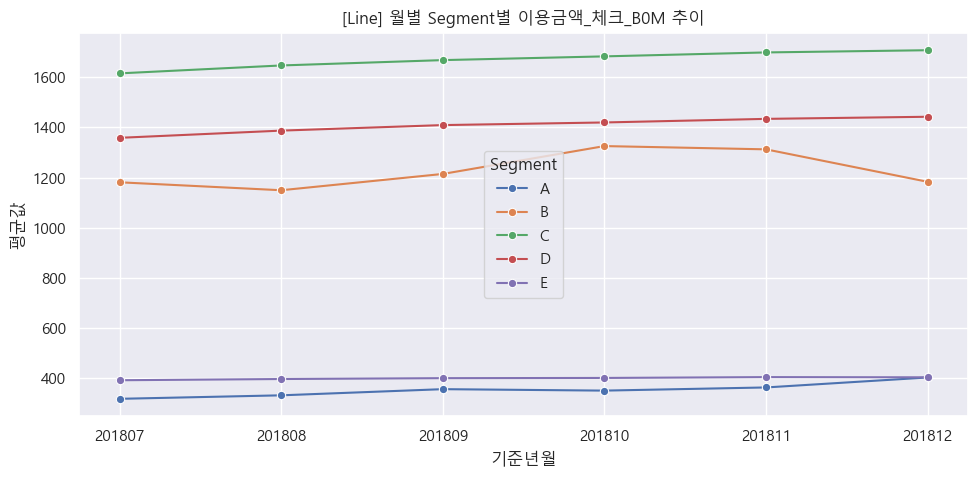

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


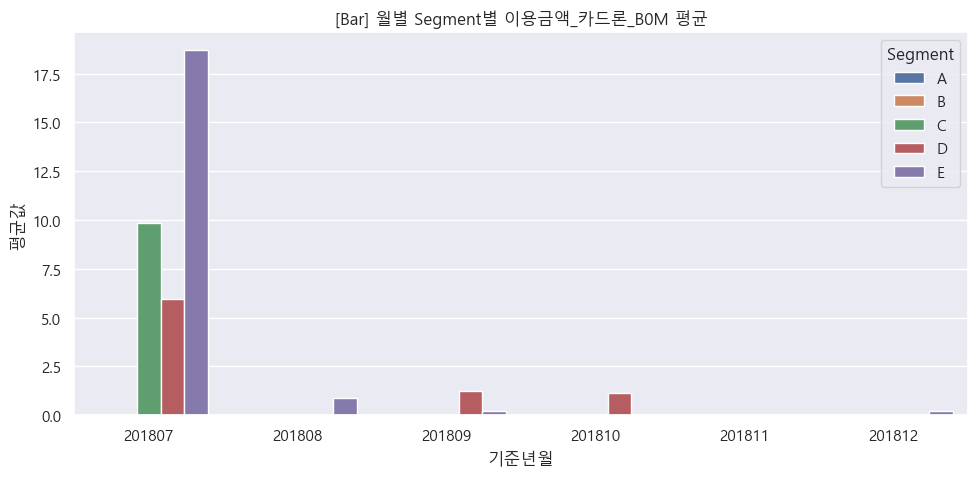

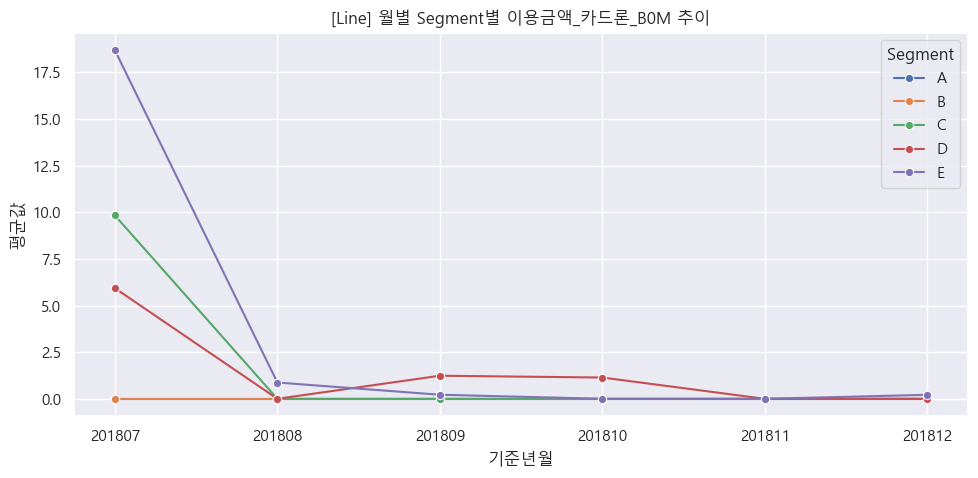

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


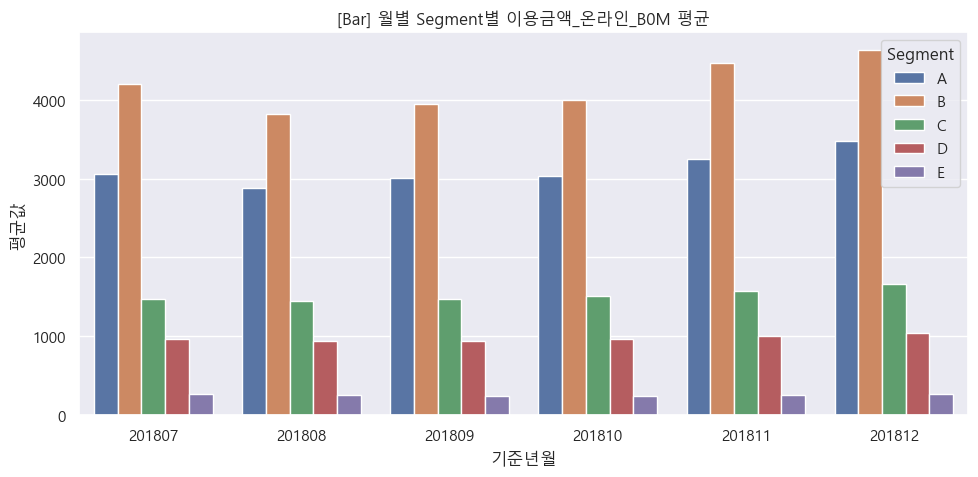

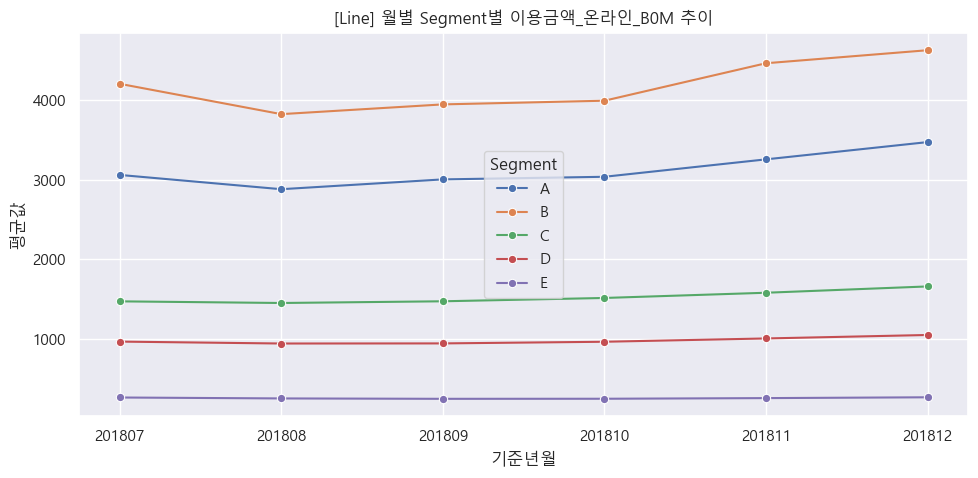

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


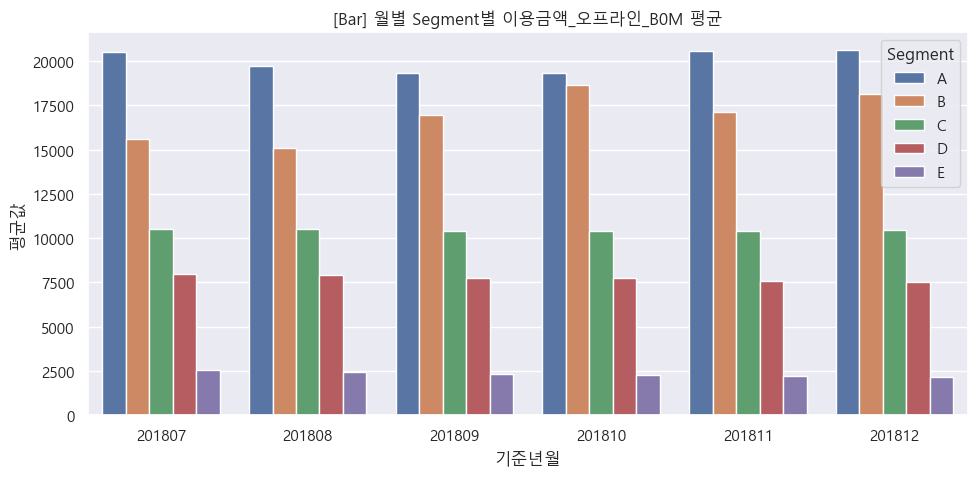

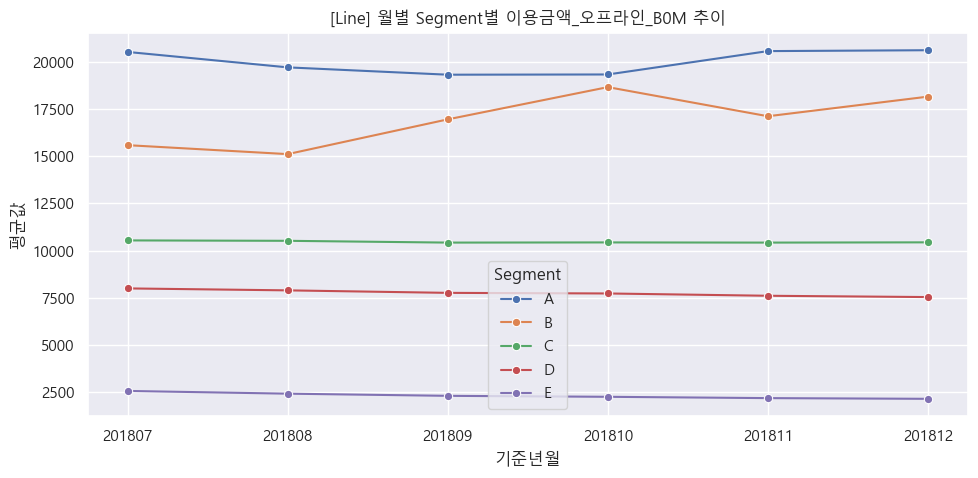

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


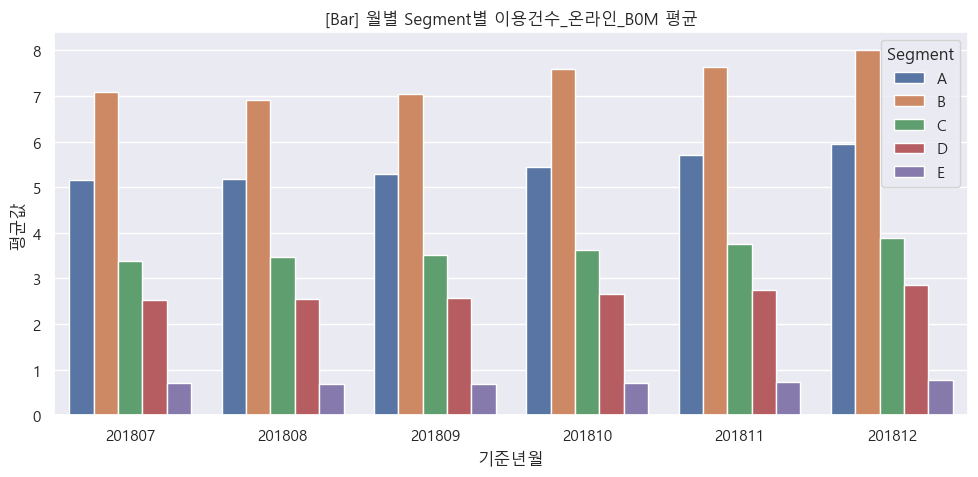

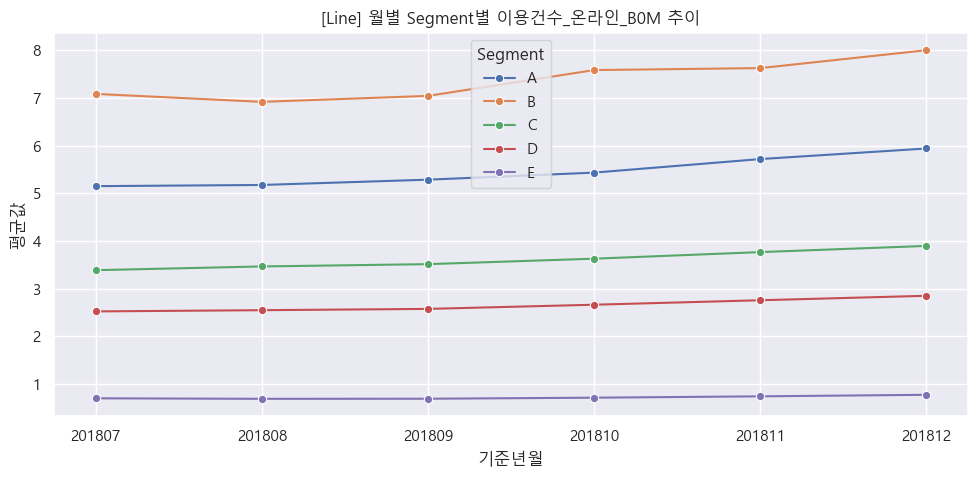

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


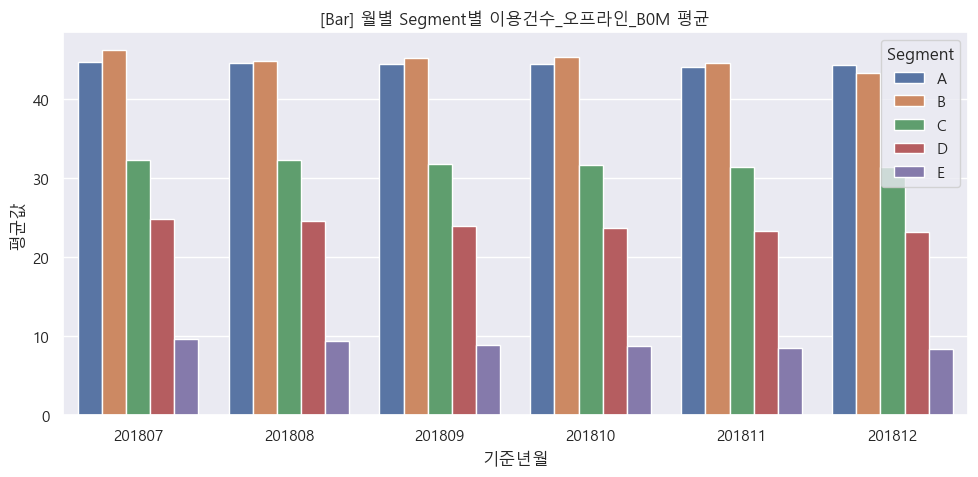

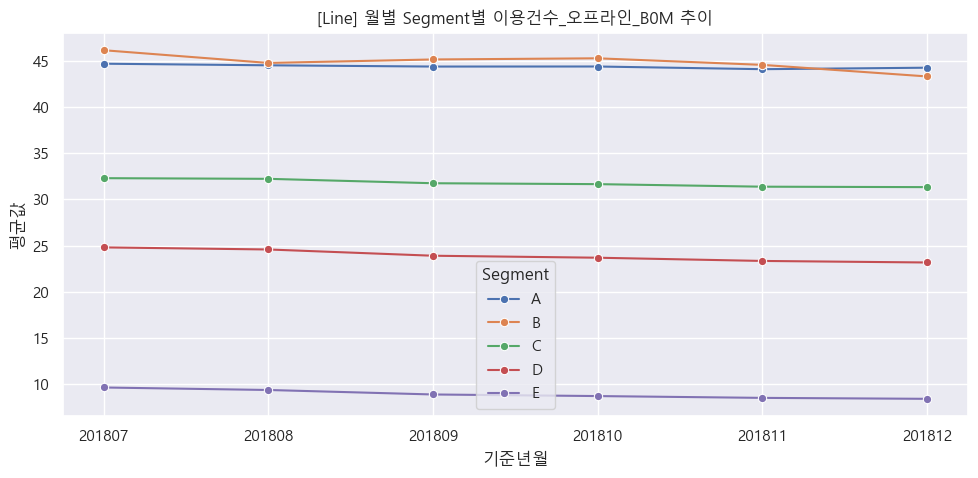

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


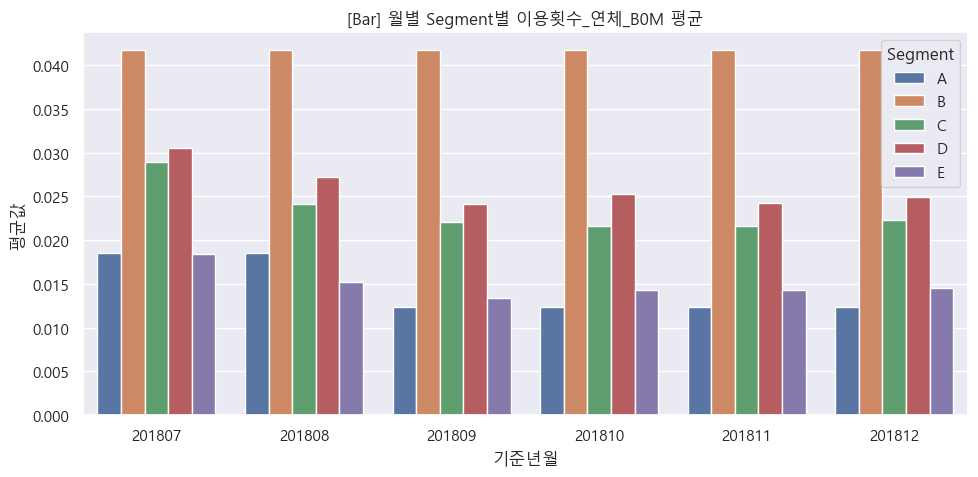

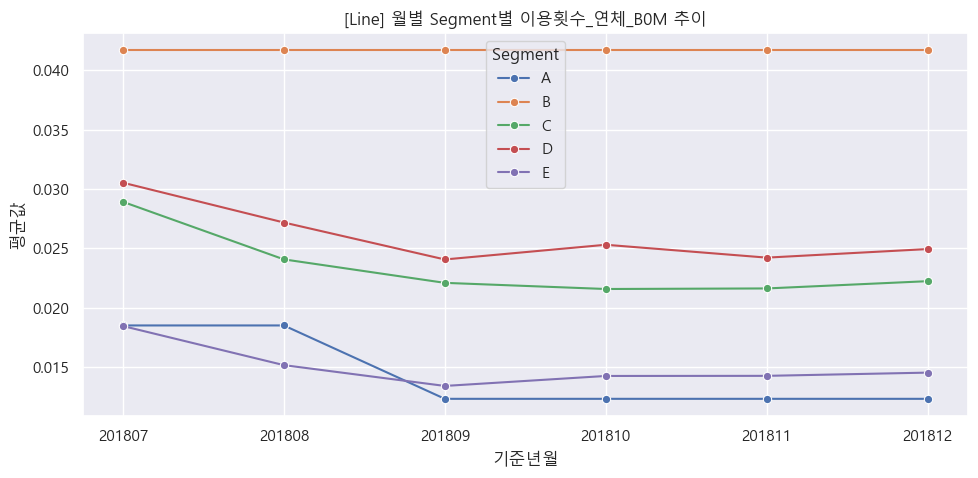

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


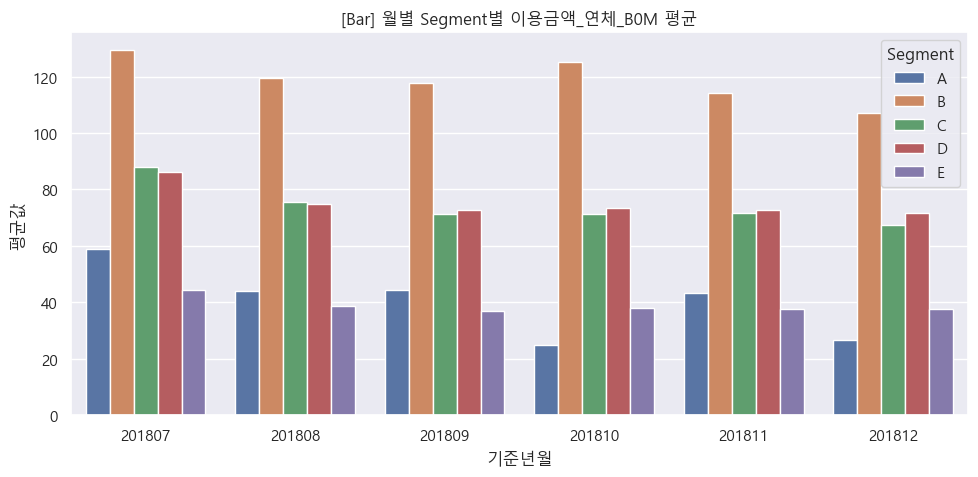

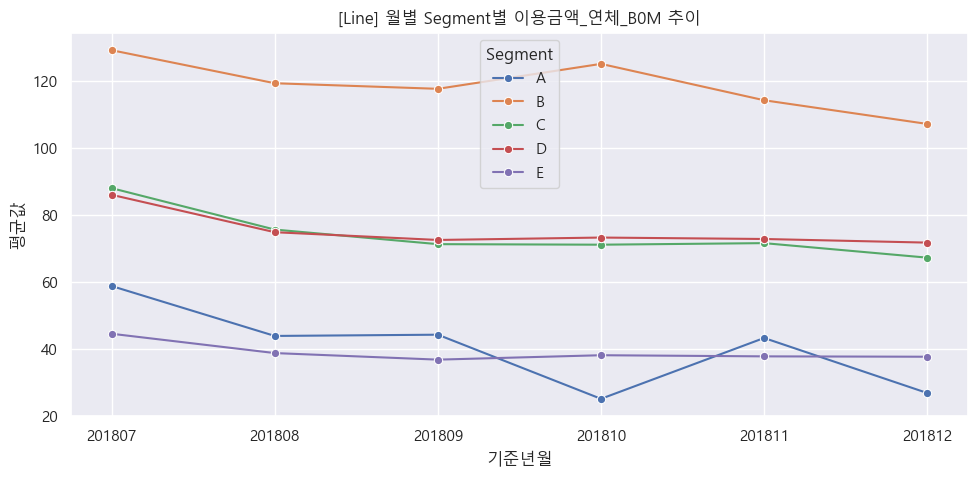

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


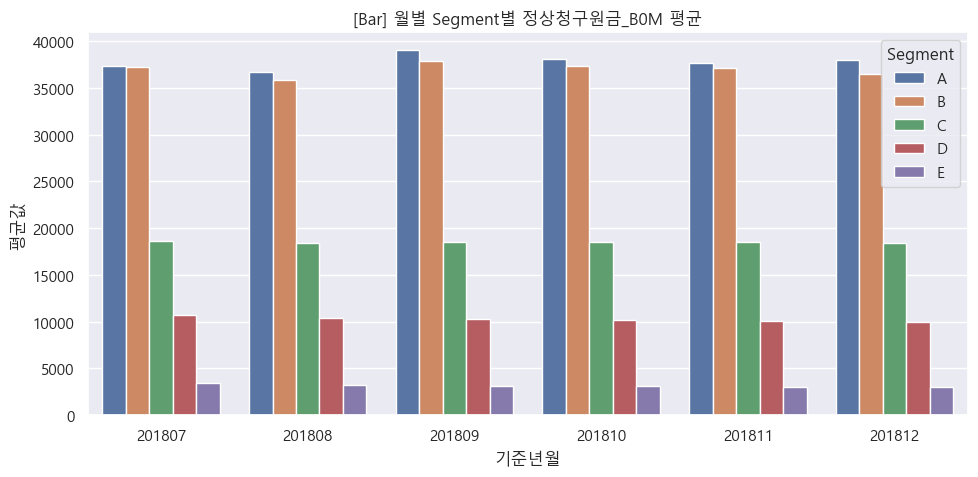

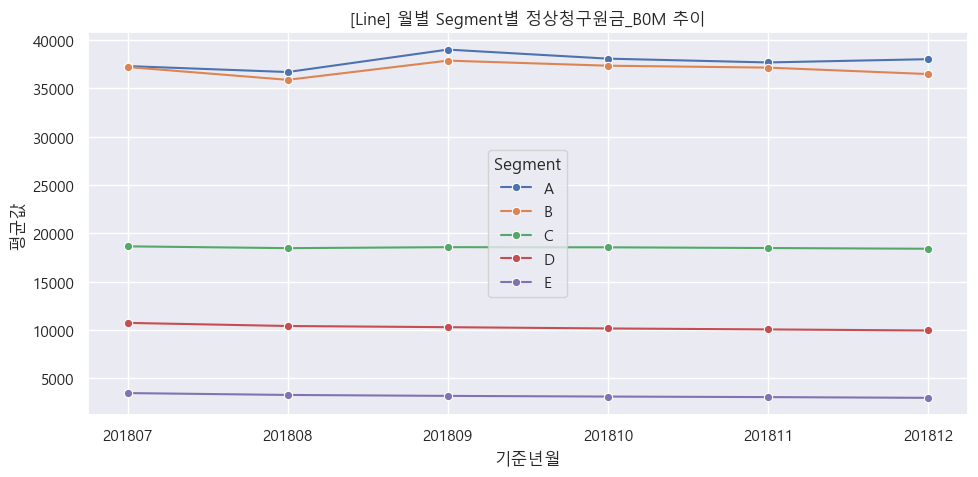

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


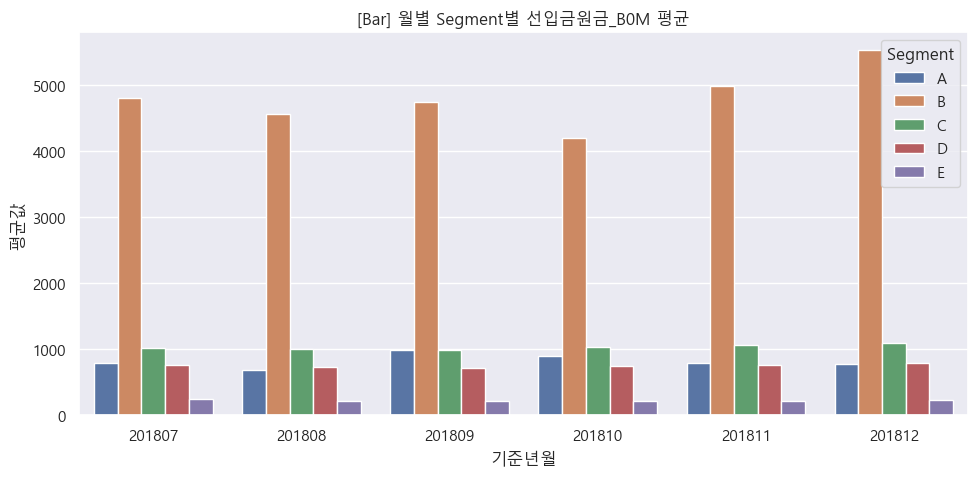

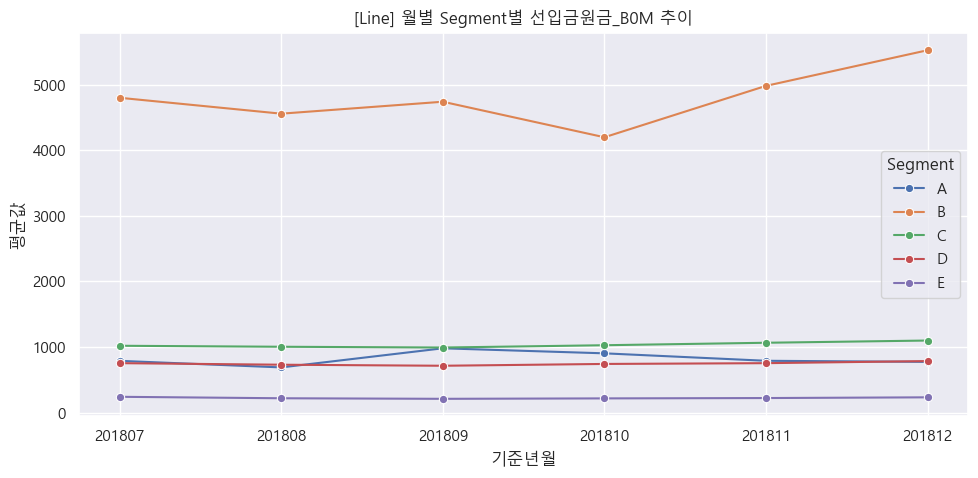

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


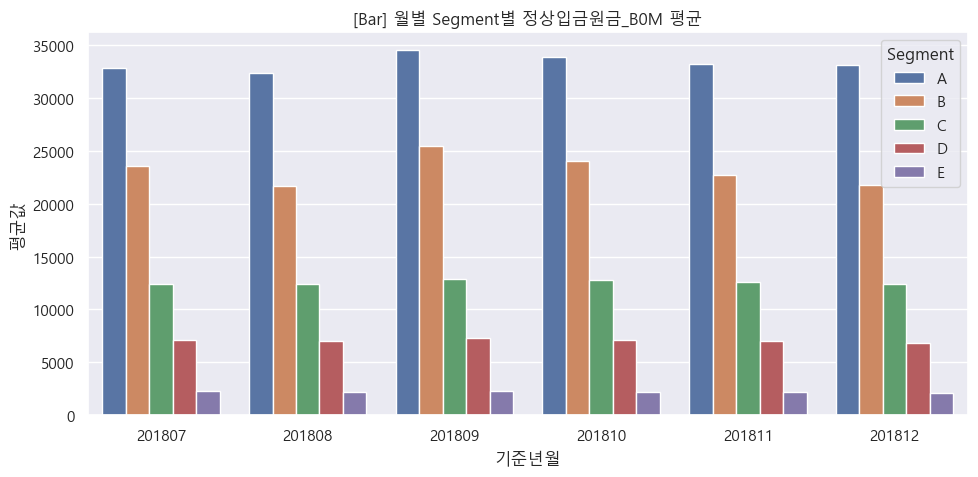

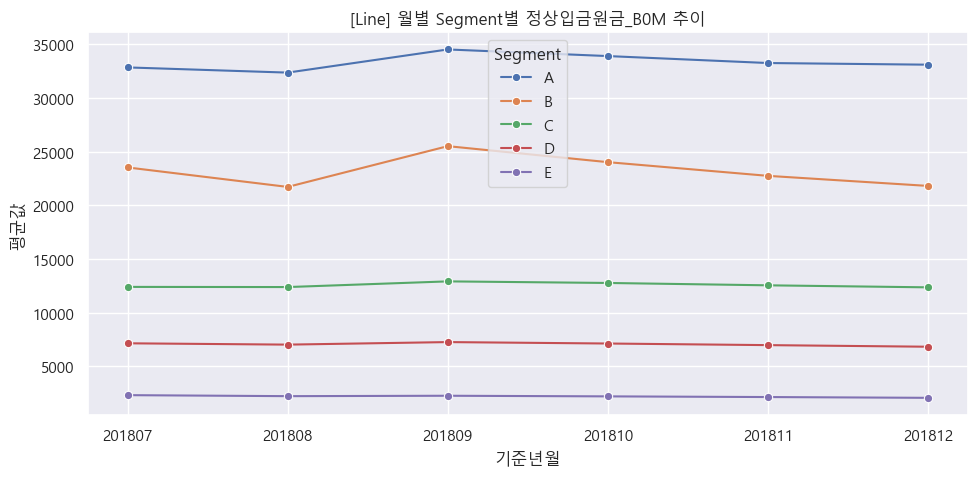

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


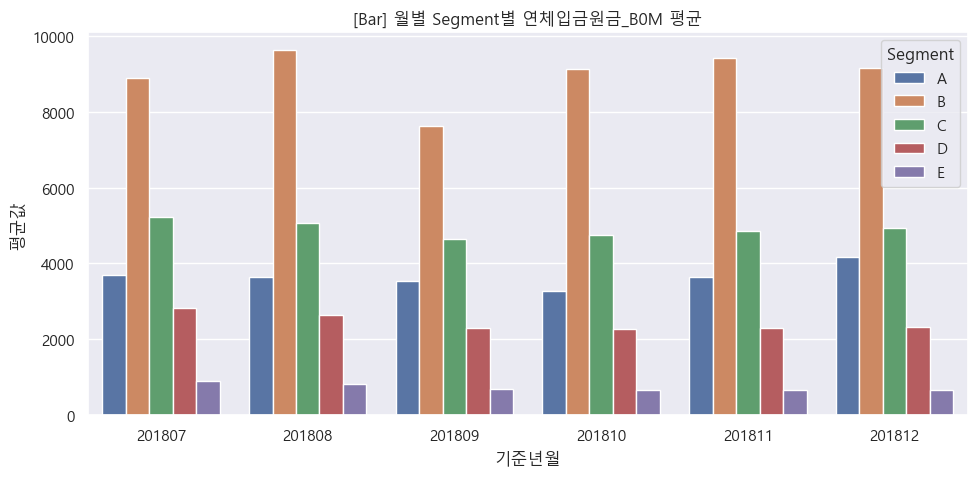

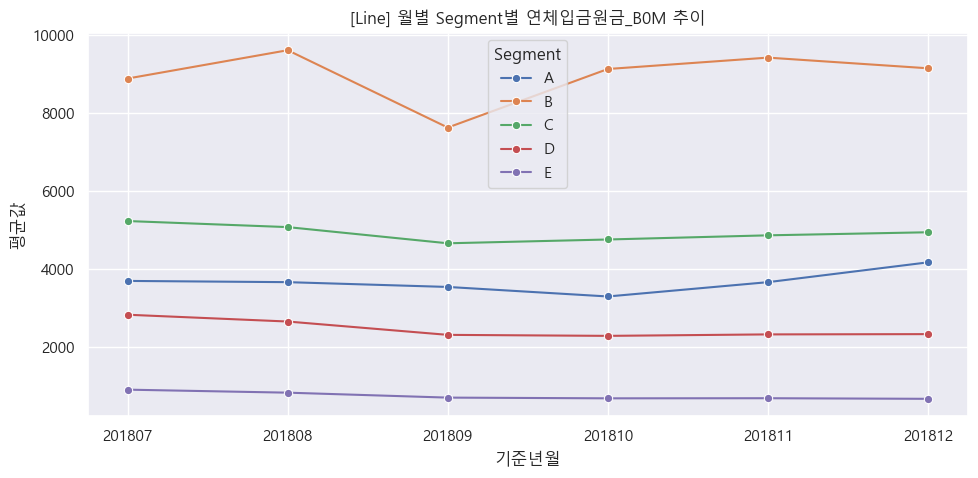

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


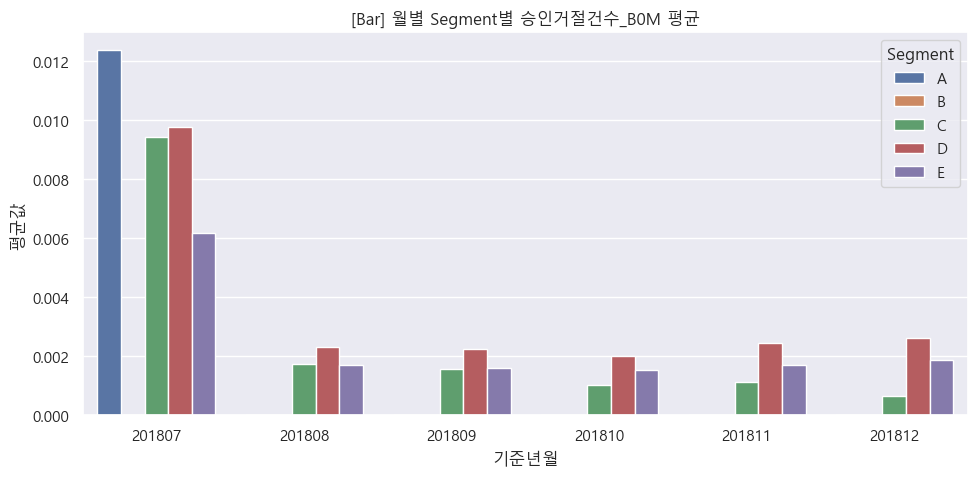

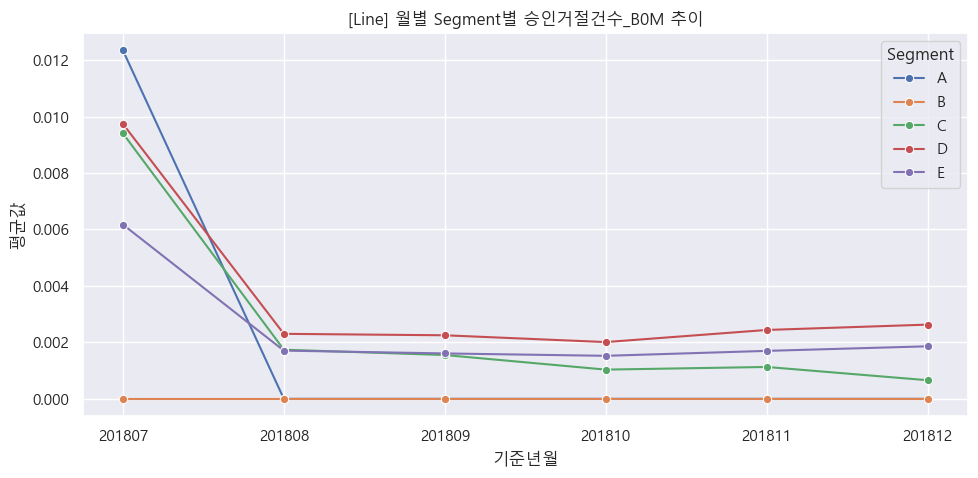

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


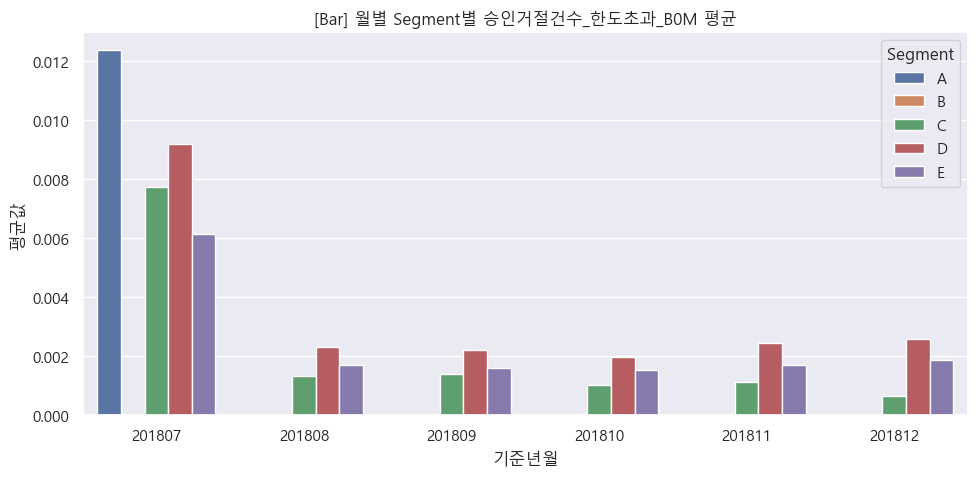

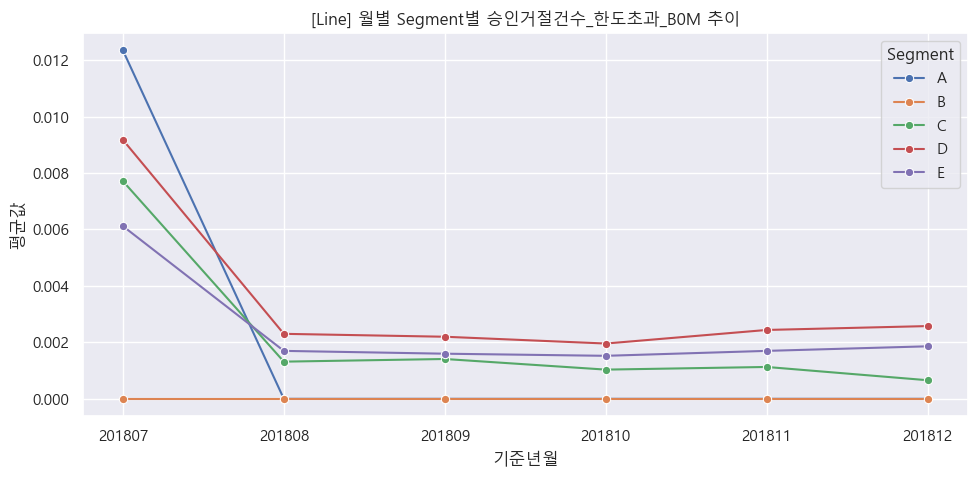

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


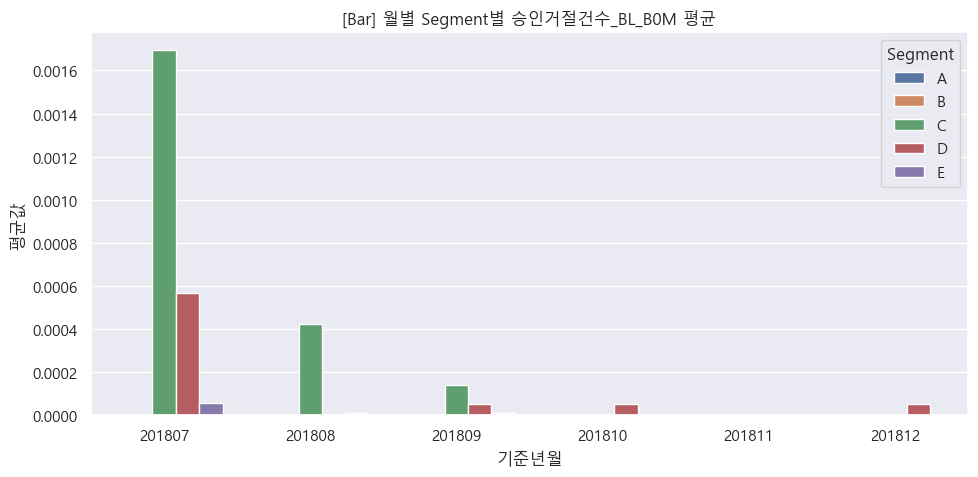

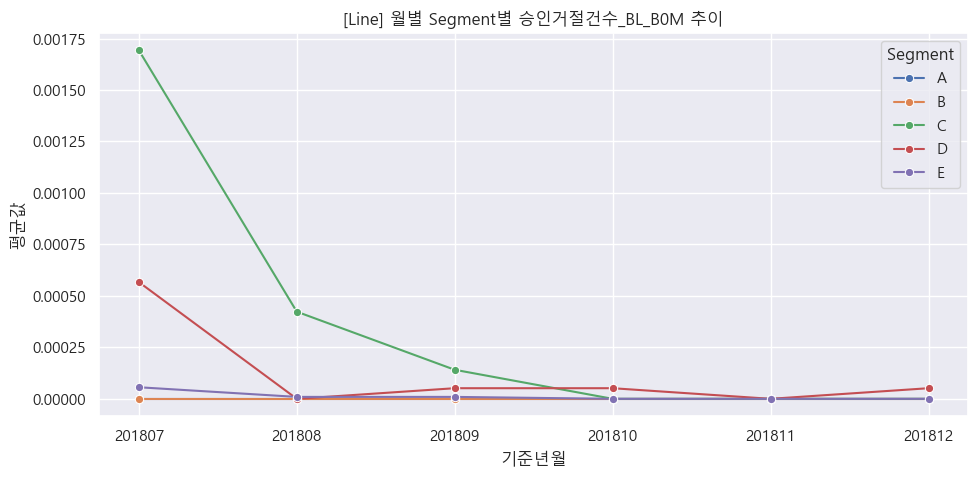

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


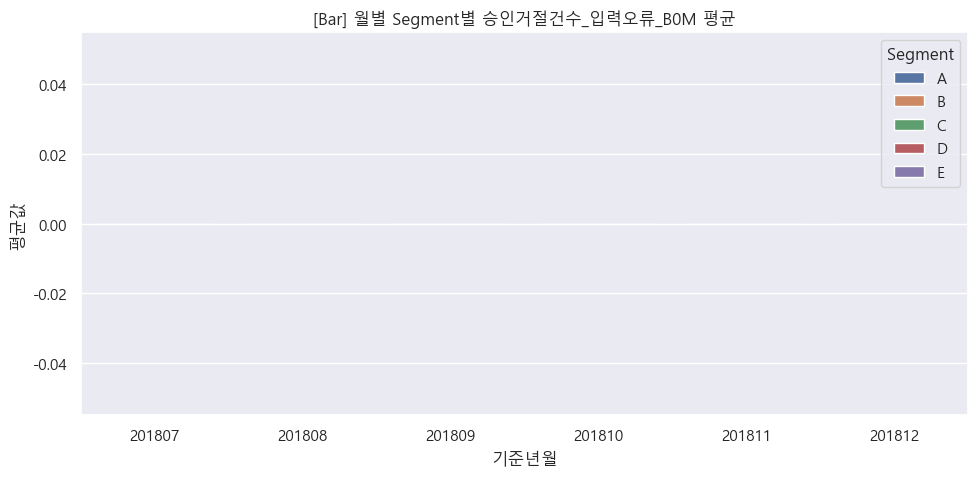

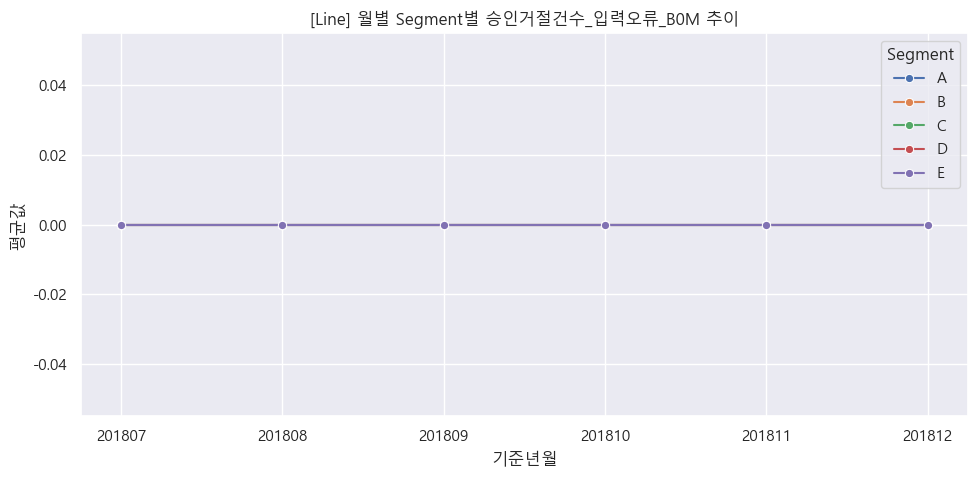

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\3220524923.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


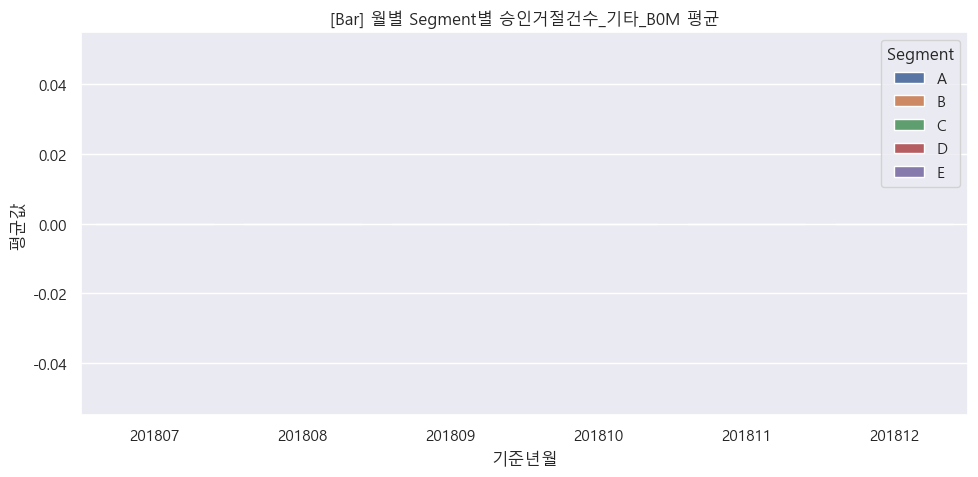

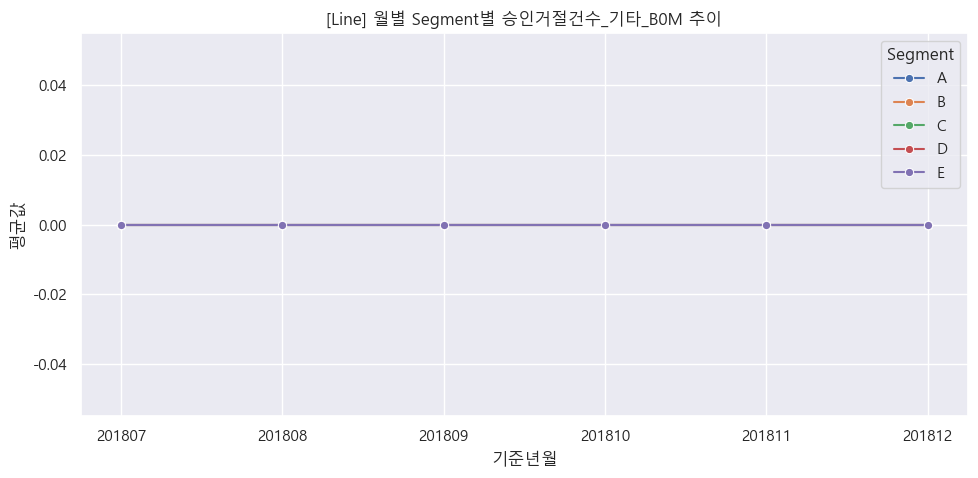

In [52]:
# 1. 데이터 불러오기
df_sales = pd.read_parquet('../data/train/3_승인매출정보_train.parquet')  # B0M 컬럼 포함
df_label = pd.read_parquet('../data/train/1_회원정보_train.parquet')  # Segment 포함

# 2. 병합: ID + 기준년월 기준
df = df_sales.merge(df_label[['ID', '기준년월', 'Segment']], on=['ID', '기준년월'], how='left')

# 3. Segment 순서 지정
segment_order = ['A', 'B', 'C', 'D', 'E']
df['Segment'] = pd.Categorical(df['Segment'], categories=segment_order, ordered=True)

# 4. 기준년월 문자열 처리
df['기준년월'] = df['기준년월'].astype(str)

# 5. 시각화 대상 컬럼
b0m_cols = [
    '이용금액_CA_B0M', '이용금액_체크_B0M', '이용금액_카드론_B0M',
    '이용금액_온라인_B0M', '이용금액_오프라인_B0M',
    '이용건수_온라인_B0M', '이용건수_오프라인_B0M',
    '이용횟수_연체_B0M', '이용금액_연체_B0M',
    '정상청구원금_B0M', '선입금원금_B0M', '정상입금원금_B0M', '연체입금원금_B0M',
    '승인거절건수_B0M', '승인거절건수_한도초과_B0M', '승인거절건수_BL_B0M',
    '승인거절건수_입력오류_B0M', '승인거절건수_기타_B0M'
]

# 6. 그래프 함수
def plot_segment_trend(col):
    group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()

    plt.figure(figsize=(10, 5))
    sns.barplot(data=group, x='기준년월', y=col, hue='Segment', order=sorted(df['기준년월'].unique()), hue_order=segment_order)
    plt.title(f"[Bar] 월별 Segment별 {col} 평균")
    plt.ylabel("평균값")
    plt.legend(title='Segment')
    plt.tight_layout()
    plt.show()

    # 선 그래프
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=group, x='기준년월', y=col, hue='Segment', hue_order=segment_order, marker='o')
    plt.title(f"[Line] 월별 Segment별 {col} 추이")
    plt.ylabel("평균값")
    plt.tight_layout()
    plt.show()

# 7. 실행
for col in b0m_cols:
    if col in df.columns:
        plot_segment_trend(col)


In [53]:
def plot_segment_trend_combined(col):
    group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=group, x='기준년월', y=col, hue='Segment',
                     order=sorted(df['기준년월'].unique()), hue_order=segment_order, alpha=0.3)

    # 선 그래프 덧그리기
    for seg in segment_order:
        seg_data = group[group['Segment'] == seg]
        sns.lineplot(data=seg_data, x='기준년월', y=col, marker='o', label=seg, ax=ax)

    plt.title(f"{col} by Segment (Bar + Line)")
    plt.ylabel("평균값")
    plt.tight_layout()
    plt.legend(title='Segment')
    plt.show()

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


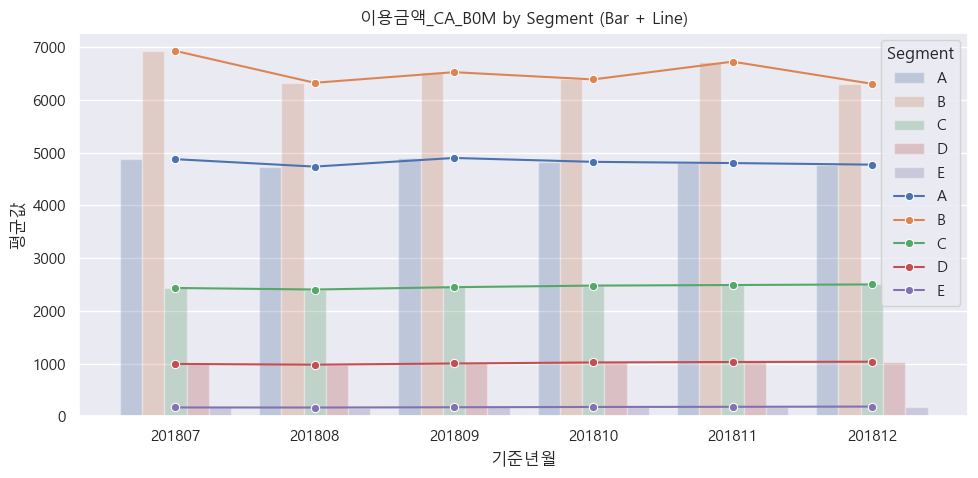

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


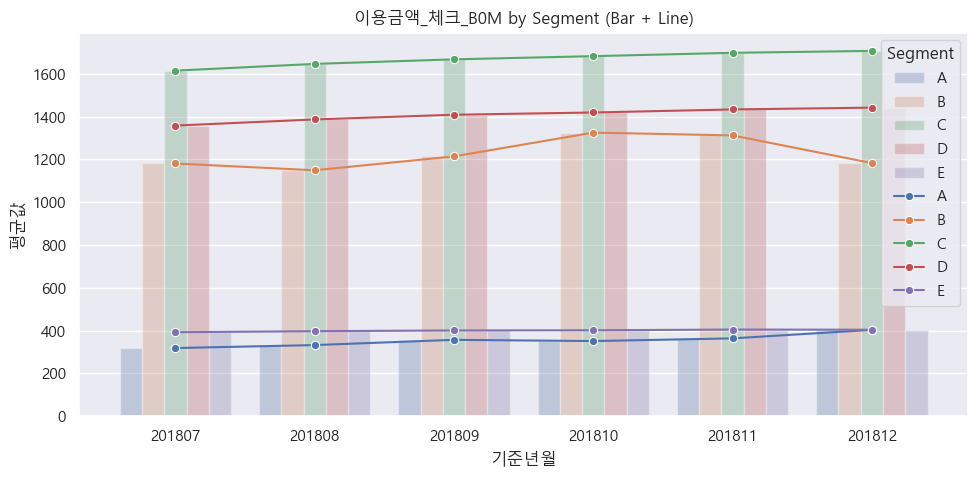

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


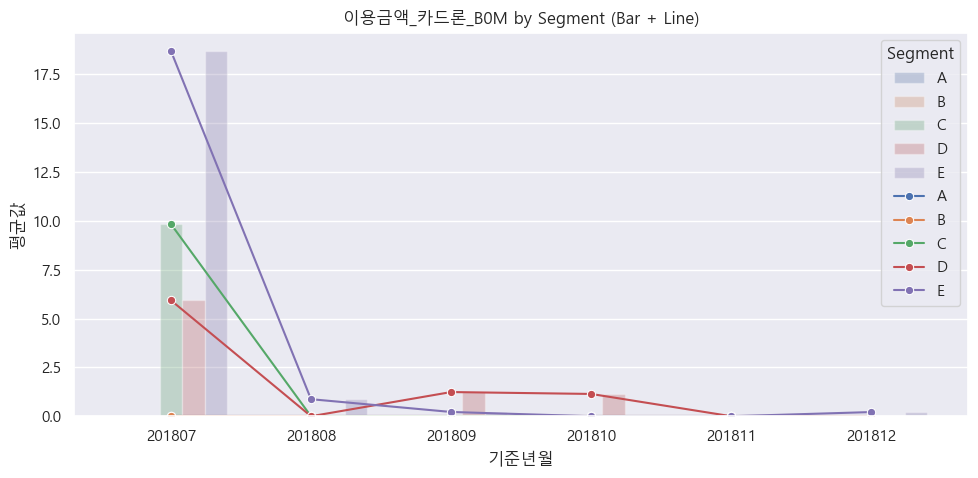

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


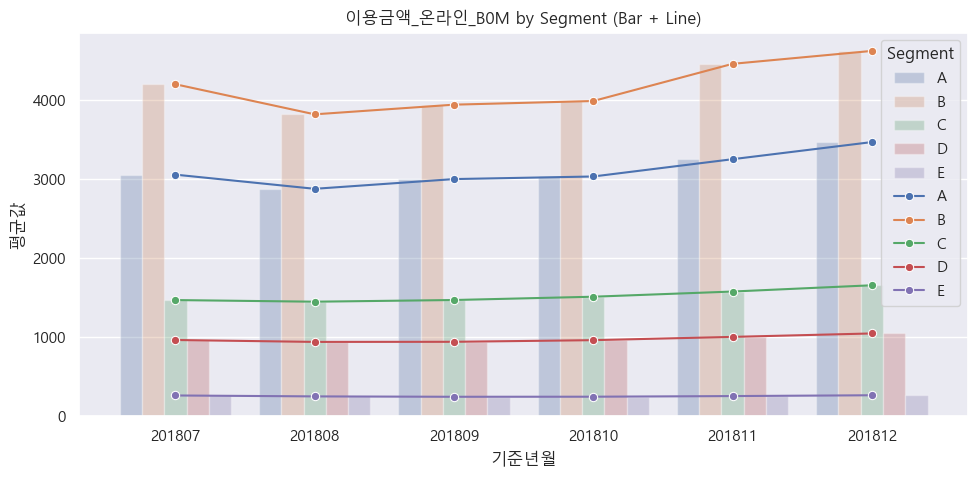

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


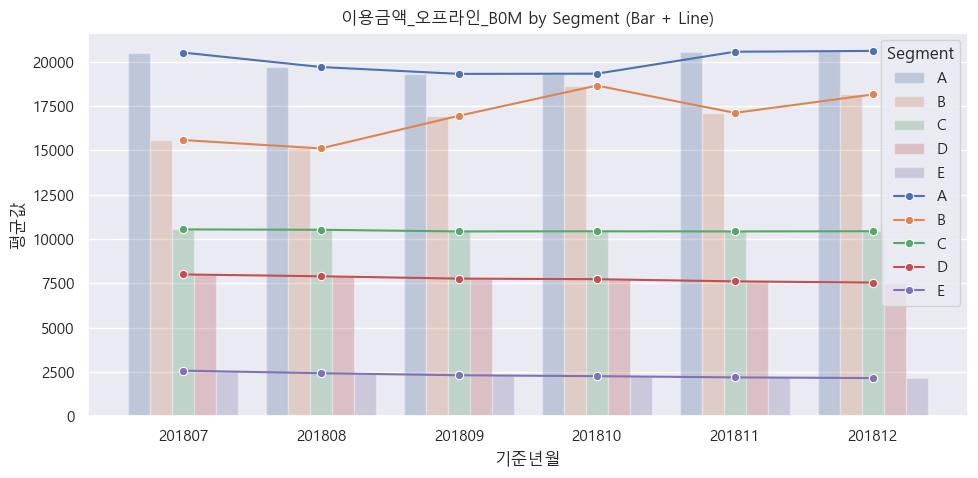

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


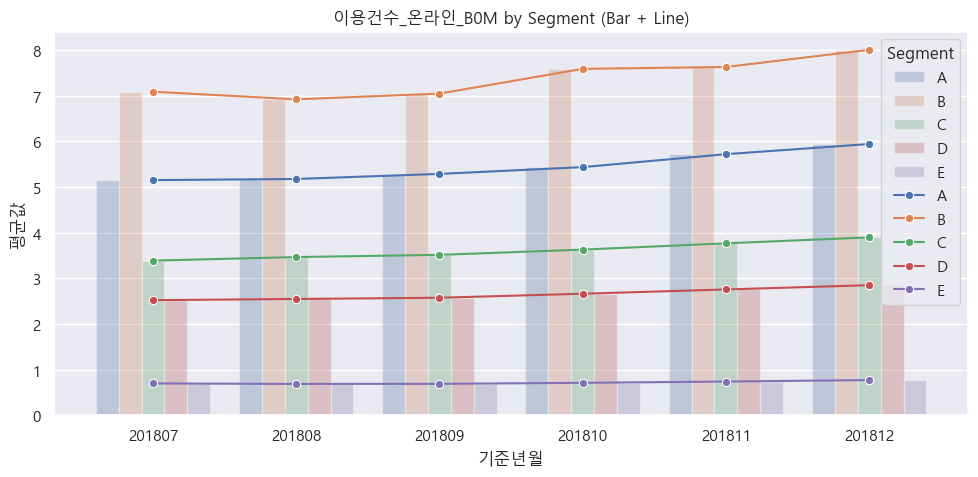

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


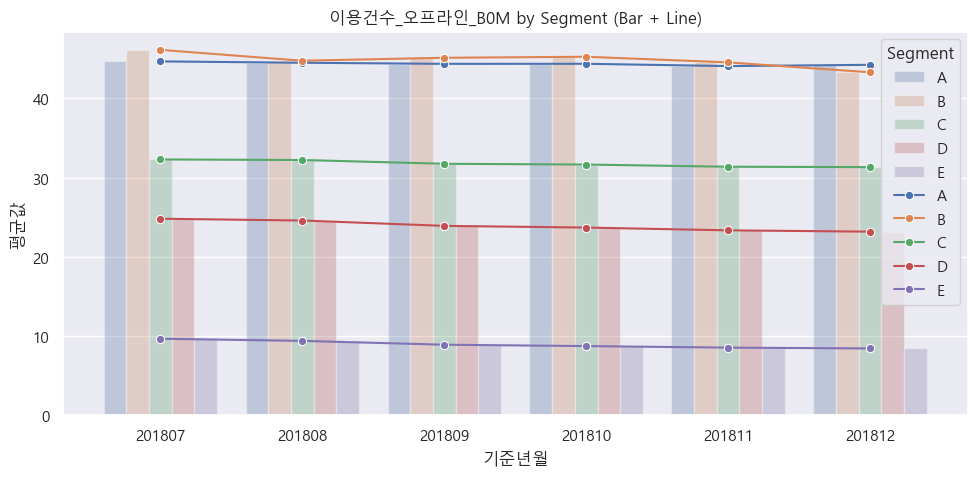

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


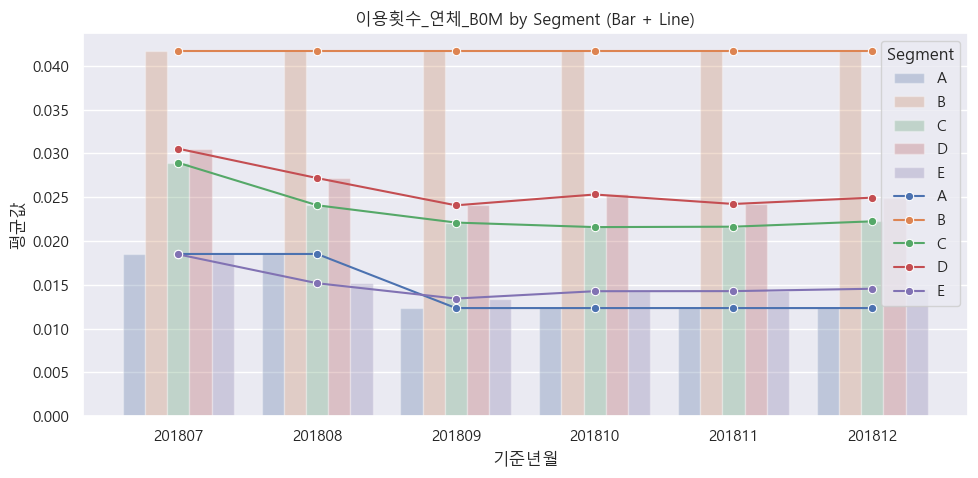

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


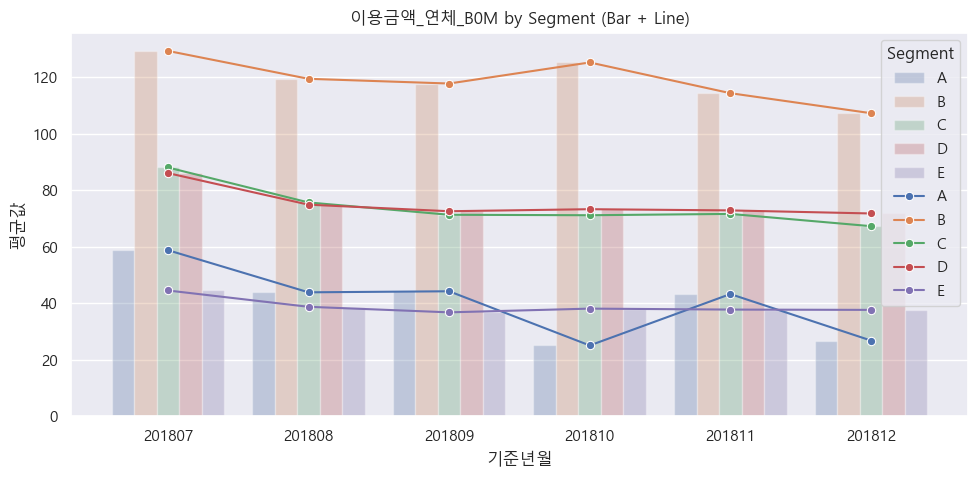

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


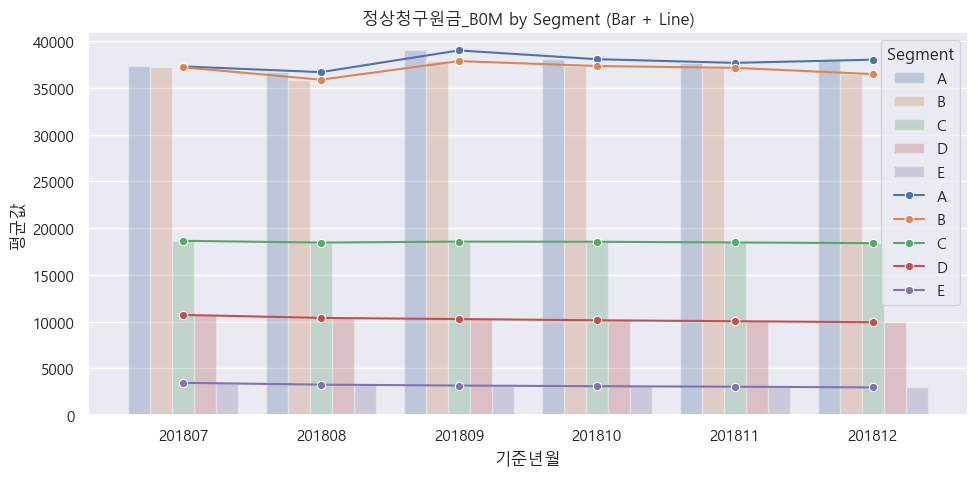

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


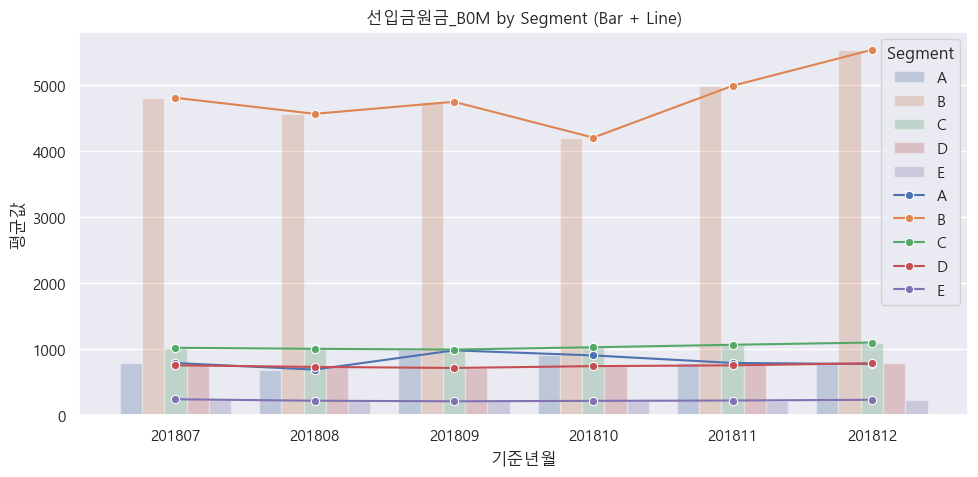

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


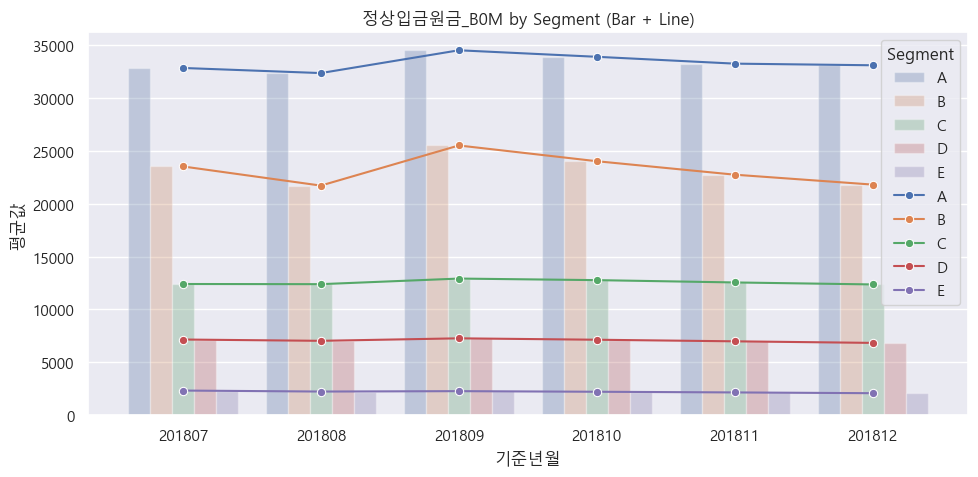

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


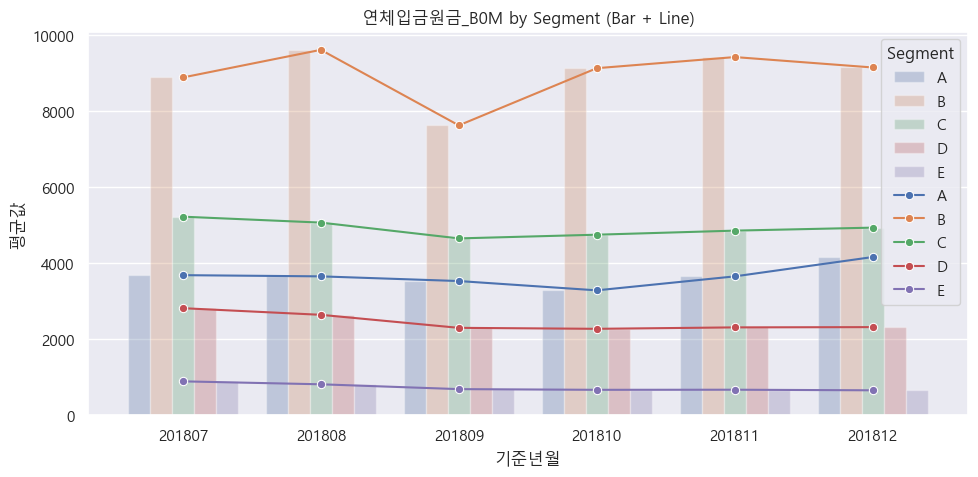

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


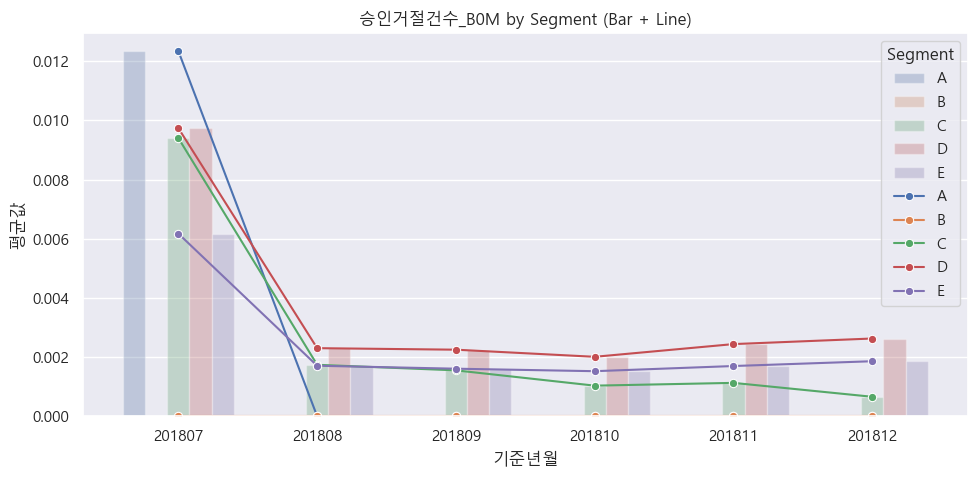

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


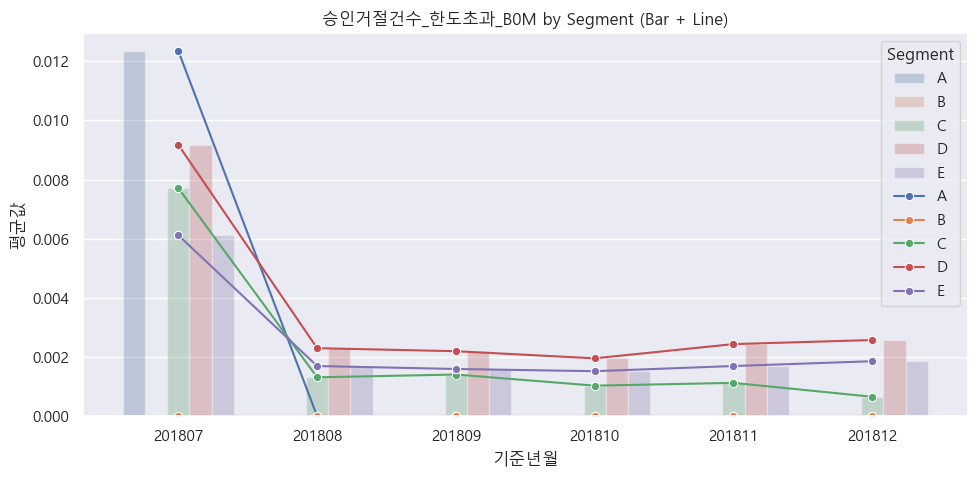

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


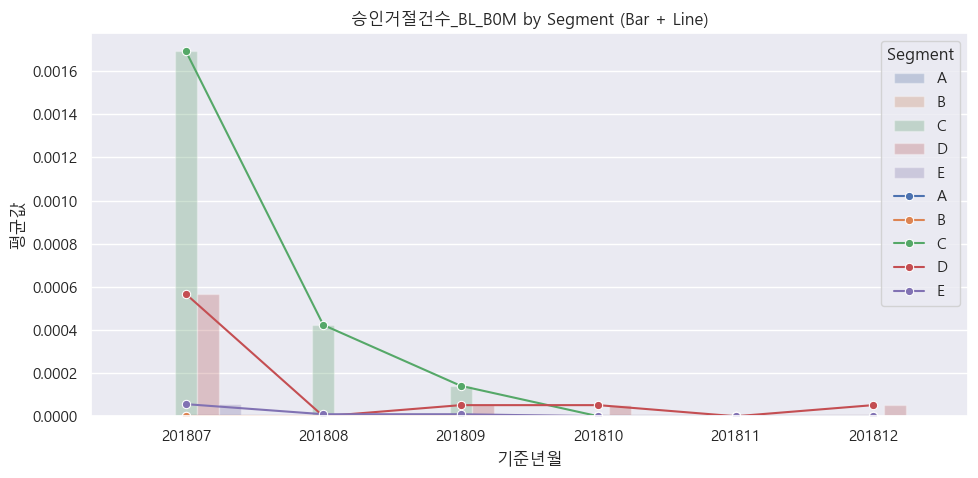

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


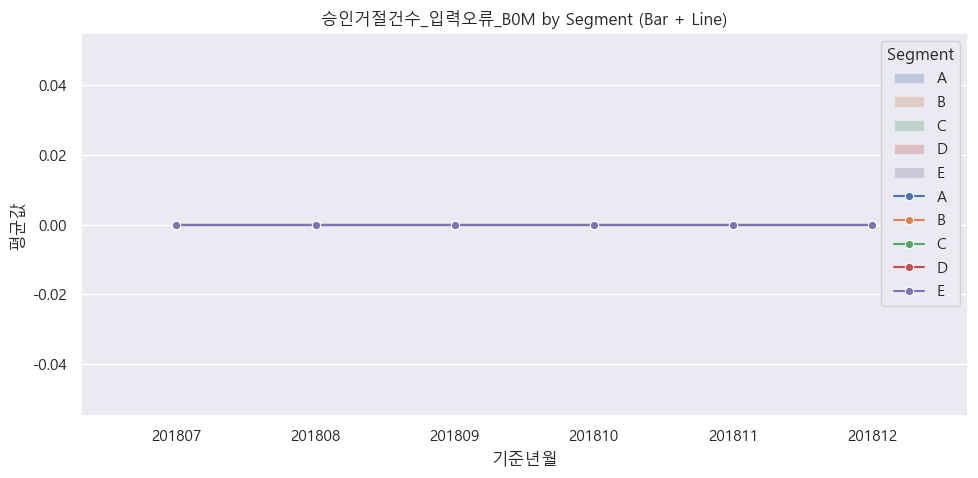

C:\Users\COTTA\AppData\Local\Temp\ipykernel_13536\2680332549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['기준년월', 'Segment'])[col].mean().reset_index()


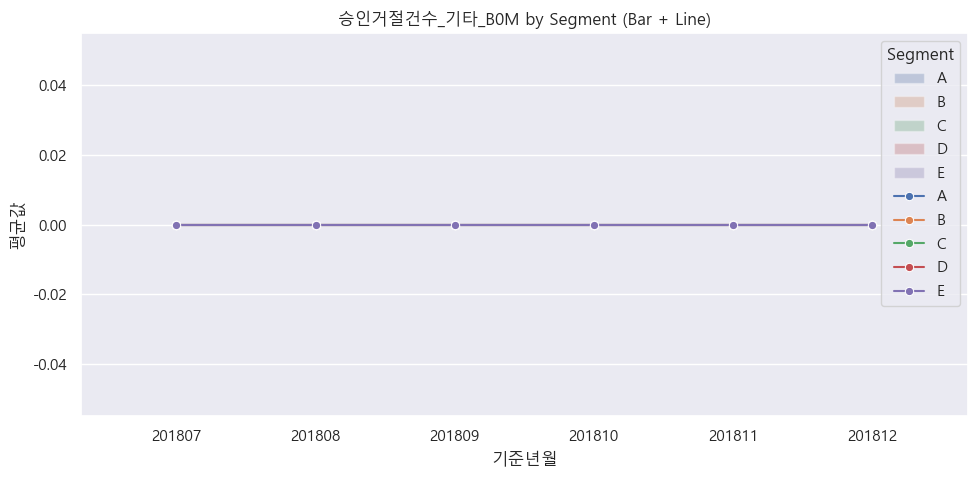

In [54]:
for col in b0m_cols:
    if col in df.columns:
        plot_segment_trend_combined(col)